# Neural Network Training Workflow with TensorFlow

In this notebook, I will practice the basic workflow for training a neural network using TensorFlow/Keras.

The focus is not on building everything from scratch yet.  
The goal is to understand how TensorFlow handles the training process using:

- `Sequential`
- `Dense layers`
- `model.compile()`
- `model.fit()`
- `model.evaluate()`
- `model.predict()`

This notebook uses a simple binary classification problem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

## 1. Creating a Simple Binary Classification Dataset

For this notebook, I will create a simple toy dataset with two classes.

Each example has two input features:

$$
x_1, x_2
$$

The target label is:

$$
y \in \{0, 1\}
$$

This keeps the focus on the TensorFlow training workflow instead of dataset complexity.

In [3]:
m = 200

# Class 0
X0 = np.random.randn(m // 2, 2) + np.array([-1, -1])
y0 = np.zeros((m // 2, 1))

# Class 1
X1 = np.random.randn(m // 2, 2) + np.array([1, 1])
y1 = np.ones((m // 2, 1))

# Combine both classes
X = np.vstack([X0, X1])
y = np.vstack([y0, y1])

# Shuffle the dataset
indices = np.random.permutation(m)
X = X[indices]
y = y[indices]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 2)
y shape: (200, 1)


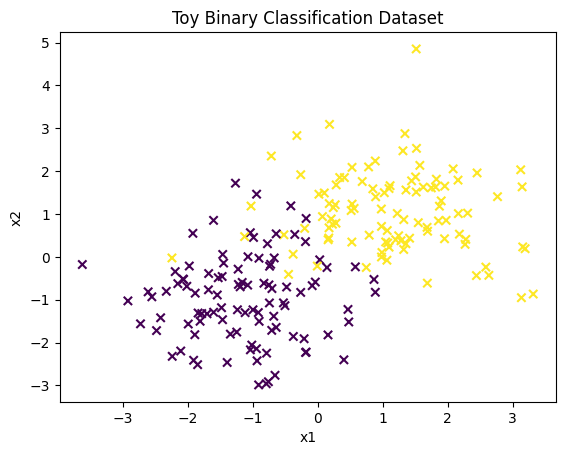

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y.reshape(-1), marker='x')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Toy Binary Classification Dataset")
plt.show()

## 2. Train/Test Split

I will manually split the dataset into training and test sets.

The training set is used to fit the model.  
The test set is used to check how well the model performs on unseen data.

In [5]:
split = int(0.8 * m)

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (160, 2)
y_train shape: (160, 1)
X_test shape: (40, 2)
y_test shape: (40, 1)


## 3. Feature Normalization

Neural networks usually train better when input features are normalized.

I will use z-score normalization:

$$
x_{norm} = \frac{x - \mu}{\sigma}
$$

The mean and standard deviation are calculated using only the training set.

In [6]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis = 0)

X_train_norm = (X_train - mu) / sigma
X_test_norm  = (X_test - mu)  / sigma

print("Mean:", mu.round(3))
print("Standard deviation:", sigma.round(3))

Mean: [0.035 0.053]
Standard deviation: [1.455 1.366]


## 4. Building the Neural Network

The model will use the Keras `Sequential` API.

For binary classification, the output layer should have:

- 1 neuron
- sigmoid activation

The sigmoid function outputs a value between 0 and 1, which can be interpreted as a probability.

In [7]:
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(8, activation="relu"),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid")
    ],
    name="binary_classification_model"
)

In [8]:
model.summary()

Model: "binary_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Compiling the Model

Before training, the model needs to be compiled.

Compilation requires:

- a loss function
- an optimizer
- optional evaluation metrics

For binary classification, a common loss function is binary cross-entropy:

$$
L = -y\log(\hat{y}) - (1-y)\log(1-\hat{y})
$$

Here:

$$
\hat{y}
$$

is the model's predicted probability.

In [9]:
model.compile(
    loss= tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate= 0.01),
    metrics=["accuracy"]
)

## 6. Training the Model

The `fit()` function trains the neural network.

During training, TensorFlow performs:

1. Forward propagation
2. Loss calculation
3. Backpropagation
4. Parameter updates

I will study backpropagation separately in another notebook.

In [10]:
history = model.fit(
    X_train_norm,
    y_train,
    epochs=100,
    verbose=0
)

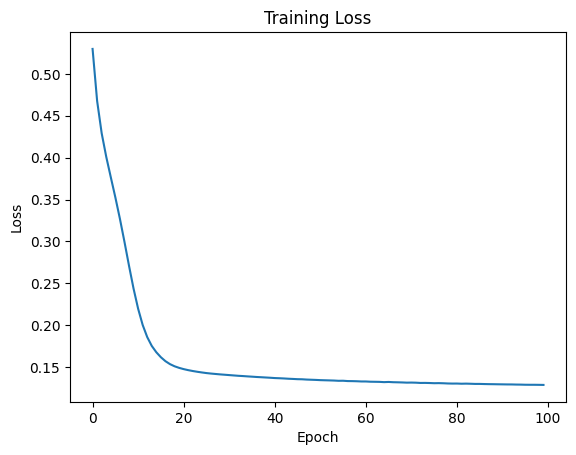

In [11]:
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

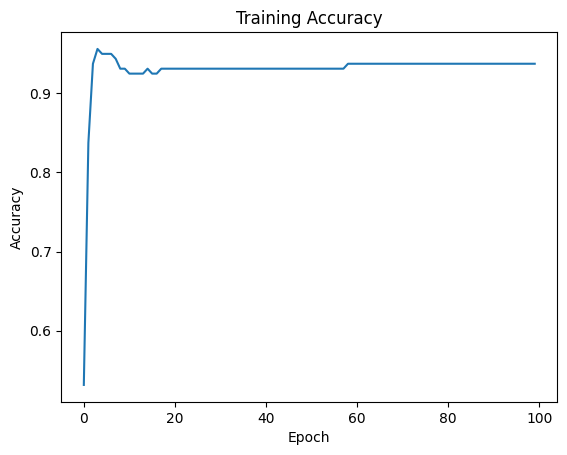

In [12]:
plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

## 7. Evaluating the Model

After training, I will evaluate the model on the test set.

This helps check whether the model can generalize to unseen data.

In [13]:
test_loss, test_accuracy = model.evaluate(X_test_norm, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.11919224262237549
Test accuracy: 0.949999988079071


## 8. Making Predictions

The model outputs probabilities.

For binary classification:

$$
\hat{y} \geq 0.5 \Rightarrow 1
$$

$$
\hat{y} < 0.5 \Rightarrow 0
$$

In [14]:
y_pred_prob = model.predict(X_test_norm, verbose = 0)

print("First 10 predicted probabilities:")
print(y_pred_prob[:10])

First 10 predicted probabilities:
[[9.9895990e-01]
 [3.4381512e-01]
 [9.9995613e-01]
 [8.7658443e-02]
 [3.5265562e-05]
 [2.7282434e-03]
 [7.1007240e-01]
 [1.1223716e-01]
 [9.9999446e-01]
 [9.9799532e-01]]


In [15]:
y_pred = (y_pred_prob >= 0.5).astype(int)

print("First 10 predicted labels:")
print(y_pred[:10].reshape(-1))

print("\nFirst 10 actual labels:")
print(y_test[:10].reshape(-1).astype(int))

First 10 predicted labels:
[1 0 1 0 0 0 1 0 1 1]

First 10 actual labels:
[1 0 1 0 0 0 1 1 1 1]


In [16]:
manual_accuracy = np.mean(y_pred == y_test)

print("Manual test accuracy:", manual_accuracy)

Manual test accuracy: 0.95


## 9. Key Takeaways

In this notebook, I practiced the basic TensorFlow training workflow.

The main steps were:

1. Create a dataset
2. Normalize features
3. Build a neural network using `Sequential`
4. Add `Dense` layers
5. Compile the model using a loss function and optimizer
6. Train the model using `model.fit()`
7. Evaluate the model using `model.evaluate()`
8. Make predictions using `model.predict()`

The important idea is that TensorFlow automates the training loop.

Internally, during training, TensorFlow performs:

- forward propagation
- loss calculation
- backpropagation
- parameter updates

Backpropagation will be explored separately from scratch in another notebook.